In [472]:
import requests
import json
import re
def query_ollama(model, task_prompt, content, temp,format_ = None, chat = None):
    url = "http://localhost:11434/api/chat"  # Эндпоинт Ollama для чата
    temperature = 0.4
    max_tokens = -1
    payload = {
        "model": model,
        "messages":[],
        "temperature": temp,
        "max_tokens": max_tokens,
        "stream": False#  # Для полного ответа без стриминга
    }
    if format_ != None:
        payload["format"] = format_
    if chat != None:
        payload["messages"]= chat
    
    payload["messages"].append({"role": "user", "content": task_prompt})
    payload["messages"].append({"role":"user", "content":content})
    response = requests.post(url, json=payload)
    
    if response.status_code == 200:
        result = response.json()
        return result["message"]["content"]
    else:
        return f"Ошибка: {response.status_code} - {response.text}"
def clean_text(text_frame):
    result_text = []
    for i in range(len(text_frame)):
        text = text_frame[i]
        cut_emoji="🟩"
        if cut_emoji:
            emoji_idx = text.find(cut_emoji)
            if emoji_idx != -1:
                text = text[:emoji_idx].strip()
            # Например: "🔹 [Текст](ссылка)" удаляется полностью
        text = re.sub(r'[🔹🟩▶️]\s*\[[^\]]*\]\([^)]*\)', '', text )
        # Сначала обрабатываем markdown-ссылки: [текст](ссылка) -> оставляем только "текст"
        text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)
        # Удаляем обычные ссылки (URL)
        text = re.sub(r'http\S+|www\S+', '', text)
                # Удаление markdown заголовков (## Заголовок -> Заголовок)
        text = re.sub(r'^#{1,6}\s+', '', text, flags=re.MULTILINE)
        
        # Удаление markdown жирного текста (**текст** -> текст)
        text = re.sub(r'\*\*(.*?)\*\*', r'\1', text)
        
        # Удаление markdown курсива (*текст* или _текст_ -> текст)
        text = re.sub(r'\*(.*?)\*', r'\1', text)
        text = re.sub(r'_(.*?)_', r'\1', text)
        
        # Удаление markdown зачеркнутого текста (~~текст~~ -> текст)
        text = re.sub(r'~~(.*?)~~', r'\1', text)
        
        # Удаление markdown кода (`код` -> код)
        text = re.sub(r'`([^`]+)`', r'\1', text)
        
        # Удаление markdown блоков кода (```код``` -> код)
        text = re.sub(r'```([^`]+)```', r'\1', text)
        
        # Обработка markdown цитат (> текст -> текст)
        text = re.sub(r'^>\s+', '', text, flags=re.MULTILINE)
        
        # Обработка markdown списков (- текст, * текст, 1. текст -> текст)
        text = re.sub(r'^[\s]*[-*+•]\s+', '', text, flags=re.MULTILINE)
        text = re.sub(r'^[\s]*\d+[.)]\s+', '', text, flags=re.MULTILINE)
    
        # Удаляем смайлы (эмодзи)
        emoji_pattern = re.compile(
            "["
            "\U0001F600-\U0001F64F"  # эмоции
            "\U0001F300-\U0001F5FF"  # символы
            "\U0001F680-\U0001F6FF"  # транспорт
            "\U0001F1E0-\U0001F1FF"  # флаги
            "\U00002700-\U000027BF"  # Dingbats
            "\U0001F900-\U0001F9FF"  # доп. символы
            "\U0001FA70-\U0001FAFF"  # символы из Unicode 13
            "]+", 
            flags=re.UNICODE
        )
        text = emoji_pattern.sub('', text)
    
        # Удаляем содержимое в скобках итеративно, пока есть что удалять
        old_text = ""
        while old_text != text:
            old_text = text
            text = re.sub(r'\([^)]*\)', '', text)  # парные круглые
            text = re.sub(r'\[[^\]]*\]', '', text) # парные квадратные
    
        # Удаляем оставшиеся непарные скобки
        text = re.sub(r'[()\[\]]', '', text)
    
        # Очищаем от лишних пробелов
        text = re.sub(r'\s+', ' ', text).strip()
        result_text.append(text)
    return result_text

In [86]:
form = {
    "type": "object",
    "properties": {
        "boolean_matrix": {
            "type": "array",
            "items": {
                "type": "boolean"
            },
            "maxItems": len(load),
            "minItems": len(load)
        }
    },
    "required": ["boolean_matrix"]
}
model = "saiga_mistral_7b"
output = query_ollama(model, bool_prompt, string_load ,form, 0.1)
res = json.loads(output)
res = res["boolean_matrix"]
print(res)

[False, True, False, False, True, False]


NameError: name 'val' is not defined

In [473]:
import pandas as pd
raw = pd.read_csv("aggregator_newsitem.csv", header = None,index_col = 0, skip_blank_lines = True)

raw.rename(columns={0: "index", 1: "title", 2:"text", 3:"shorten_text", 4:"link",
                     5: "posted", 6:"scanned", 7: "processed", 8:"source_id"}, inplace=True)
raw = data.dropna()
#print(len(data))
cleaned_data = raw#  очистка текста от скобок, эмодзи, markdown и ссылок 
cleaned_data["text"] = clean_text(raw["text"].tolist())

In [475]:
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

# Эффективное вычисление всех эмбеддингов ОДНИМ вызовом (в 50–100 раз быстрее твоего цикла)
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
embeddings = model.encode(cleaned_data["text"].tolist(), normalize_embeddings=True, batch_size=64, show_progress_bar=True)

# Полная матрица косинусного сходства за один dot-product
similarity_matrix = np.dot(embeddings, embeddings.T)          # значения от -1 до 1
distance_matrix = 1 - similarity_matrix
np.fill_diagonal(distance_matrix, 0)

# Посмотри реальное распределение сходств (это ключевой шаг!)
print("Перцентили сходства (без диагонали):")
row_inds, col_inds = np.triu_indices_from(similarity_matrix, k=1)
vals = similarity_matrix[row_inds, col_inds]
print(np.percentile(vals, [50, 70, 80, 90, 95, 99]))

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Перцентили сходства (без диагонали):
[0.21433686 0.30304702 0.3603614  0.44198881 0.5131565  0.65444814]


Получено кластеров: 266


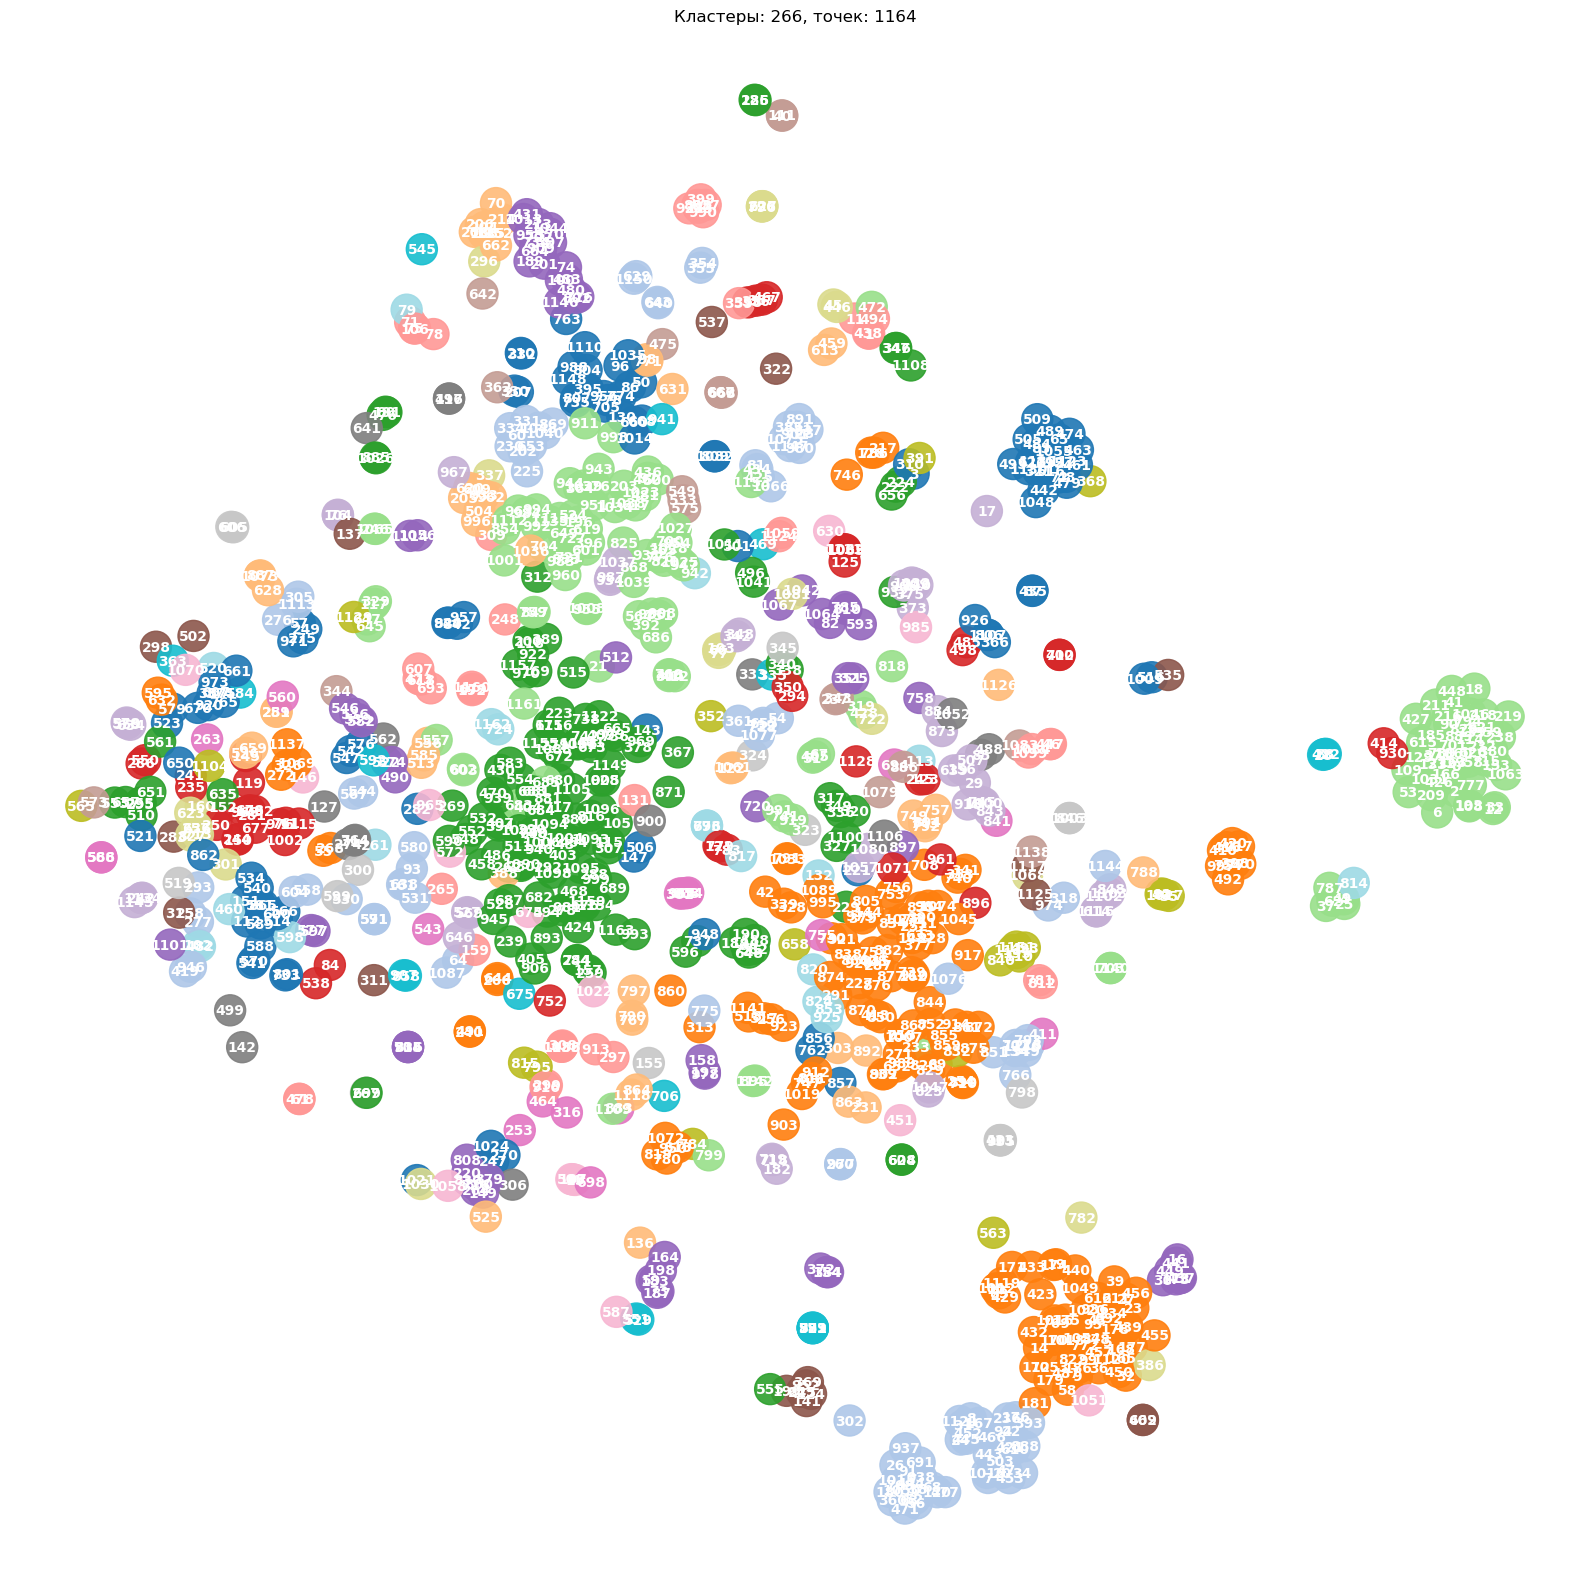

In [517]:

# Агломеративная кластеризация с расстоянием, соответствующим твоим данным
# Подбери distance_threshold чуть выше 95–99 перцентиля расстояния (или 1 - 90-й перцентиль сходства)
clustering = AgglomerativeClustering(
    n_clusters=None,
    metric='precomputed',
    linkage='average',
    distance_threshold=0.6   # ← вот сюда ставь 1 - твой 90–95 перцентиль из print выше
)
# 0.55 - norm
cluster_id = clustering.fit_predict(distance_matrix)
n_clusters = len(set(cluster_id))
print(f"Получено кластеров: {n_clusters}")

cleaned_data["id"] = cluster_id

# Визуализация через t-SNE на расстояниях — похожести будут физически рядом
pos = TSNE(
    n_components=2,
    metric='precomputed',
    perplexity=30,
    random_state=42,
    init='random'
).fit_transform(distance_matrix)

n_points = pos.shape[0]   # ← реальное количество точек

plt.figure(figsize=(16, 16))
scatter = plt.scatter(pos[:, 0], pos[:, 1], c=cluster_id, cmap='tab20', s=500, alpha=0.9)

# Цикл строго по реальному числу точек
for i in range(n_points):
    plt.text(pos[i, 0], pos[i, 1], str(i), fontsize=10, ha='center', va='center', 
             color='white', weight='bold', zorder=10)

plt.title(f'Кластеры: {n_clusters}, точек: {n_points}')
plt.axis('off')
plt.tight_layout()
plt.savefig("clusters.png")
#plt.show()

In [483]:
print("\n\n".join(cleaned_data[cleaned_data["id"] == 4]["text"]))

В августе рост российской экономики остановился — ВВП показал нулевую динамику месяц к месяцу , оценило Минэкономики. Рост в годовом выражении остался таким же, как и в июле — 0,4% г/г. Сильнее всего экономику замедляют добывающие отрасли и строительство, переживающие спад. Годовой рост сохраняется в основном благодаря секторам, связанным с ВПК, и ускоряющему потреблению. По итогам всего года ВВП должен увеличиться на 1% после 4,3% в 2024 году, прогнозируют в Минэке. ЦБ ожидает роста экономики в диапазоне 1-2%. Но, с учетом последних данных, достичь даже такого результата будет непросто, предупреждают эксперты. Что будет с экономикой дальше, впишется ли рост ВВП в прогнозы властей и как это повлияет на ключевую ставку — в материале РБК. Самые важные новости — в телеграм-канале РБК

⏺Индекс Мосбиржи в ходе вечерней сессии впервые с 9 апреля опустился ниже 2600 пункта На 19:08 мск российский индикатор терял 1,1%, до 2599,79 пункта. «Факторов для оптимизма не хватает — жесткая геополитика

In [518]:
classes, counts = np.unique(cluster_id, return_counts = True)
mask_classes = [False]*len(classes)
for i, counter in enumerate(counts):
    if counter >= 5:
        mask_classes[i] = True
mask_points = [False]*len(cleaned_data)
for ind, elem in enumerate(cluster_id):
    if mask_classes[elem] == True:
        mask_points[ind] = True

In [ ]:
for i in range(len(mask_classes)):
    print(f"class {classes[i]} count {counts[i]} included {mask_classes[i]}")

C:\Users\trinimate\AppData\Local\Temp\ipykernel_19648\4028568116.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\trinimate\AppData\Local\Temp\ipykernel_19648\4028568116.py:11: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



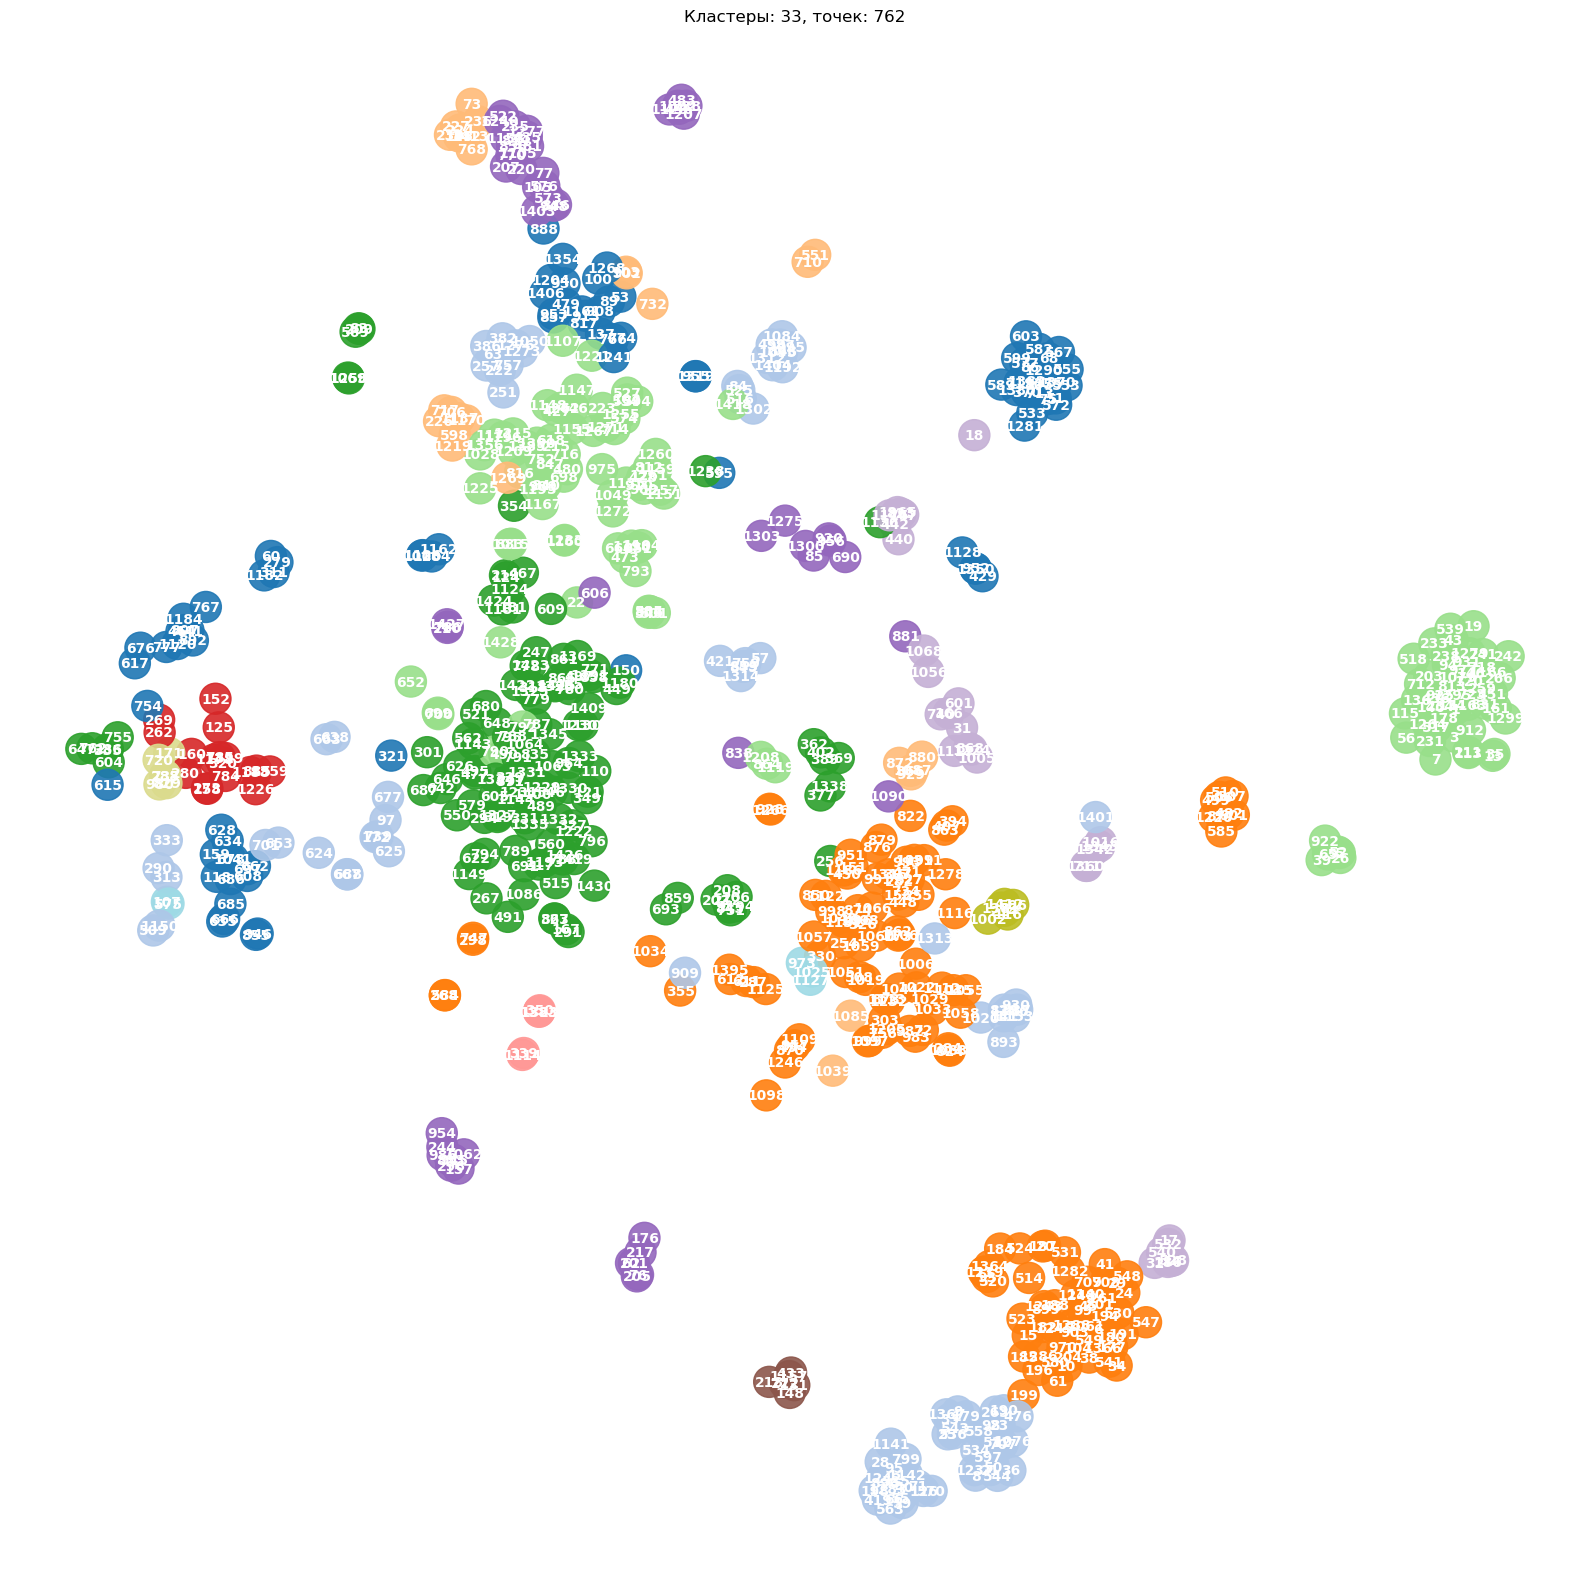

In [519]:
filtered_pos = pos[mask_points]
filtered_data = cleaned_data[mask_points]
filtered_data["index"] = filtered_data.index
_points =filtered_pos.shape[0]   # ← реальное количество точек

plt.figure(figsize=(16, 16))
scatter = plt.scatter(filtered_pos[:, 0],filtered_pos[:, 1], c=filtered_data["id"].to_numpy(), cmap='tab20', s=500, alpha=0.9)

# Цикл строго по реальному числу точек
for i in range(_points):
    plt.text(filtered_pos[i, 0], filtered_pos[i, 1], str(filtered_data["index"][i]), fontsize=10, ha='center', va='center', 
             color='white', weight='bold', zorder=10)

plt.title(f'Кластеры: {np.unique(mask_types,return_counts = True)[1][1]}, точек: {_points}')
plt.axis('off')
plt.tight_layout()
plt.savefig("clusters_filtered.png")
#plt.show()

In [520]:
import plotly.express as px
import pandas as pd
plot_pd = pd.DataFrame({"x":filtered_pos[:, 0], "y":filtered_pos[:, 1],"color" : filtered_data["id"].to_numpy() ,
                        "idx" : filtered_data["index"].to_numpy(), "text":[filtered_data["text"][i][0:90] for i in filtered_data["index"]] })
plot_pd['color_category'] = plot_pd['color'].astype('category')
fig = px.scatter(
    plot_pd, x='x', y='y',
    hover_data=['idx', "text"],  # Дополнительная информация при наведении
    color = "color_category"
)

fig.update_traces(
    textposition='top center',
    textfont_size=12
)
fig.write_html('topics.html')
fig.show(renderer='iframe')

In [419]:
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
topic_texts = clean_text(pd_filtered_cluster_id[pd_filtered_cluster_id["id"] == 86]["text"].tolist())
print(len(topic_texts))

18


In [420]:
stop_words_headlines = ["вот", "что", "как", "почему", "громкое", "сенсационное", "скандальное", "шокирующее", "невероятное", "эксклюзив",
                        "стало известно", "раскрыты детали", "обнародовано", "оказалось", "выяснилось", "внезапно", "неожиданно", "срочно", 
                        "экстренно", "без комментариев", "смотрите", "только что", "новое", "главное", "итоги", "ситуация", "резонансное", 
                        "разразился", "обвал", "взрывное", "это", "просто", "уже", "еще", "очень", "самое", "началось", "закончилось",
                        "история", "реакция", "после", "все", "никто", "что произошло", "что известно", "ход", "новость", "снова", "опять", "детали",
                       'без', 'известно', 'комментариев', 'произошло', 'раскрыты', 'стало', 'только', 'на']

In [422]:
# Находим центроид (средний вектор всей группы)
temp_embeddings = model.encode(topic_texts, normalize_embeddings=True, batch_size=64, show_progress_bar=True)
centroid = np.mean(temp_embeddings, axis=0)

# Находим 5 текстов, ближайших к центроиду (самые "типичные")
distances = np.linalg.norm(temp_embeddings - centroid, axis=1)
top5_indices = np.argsort(distances)[:7]
representative_texts = [topic_texts[i] for i in top5_indices]
combined = "\n\n---\n\n".join(representative_texts)
print(combined)
print("--------------")
prompt = f"""Это 5 вариантов одной и той же новости из разных источников.
Сформулируй ОДИН нейтральный, максимально точный и ёмкий заголовок, который подходит всем версиям сразу, на русском языке.
В случае, когда новости касаются одного события, но взаимодополняют друг друга, назови СОБЫТИЕ
Не выводи ничего, кроме ответа.
Новость:
{combined}

Заголовок:"""
model_llm = "saiga_mistral_7b"
output = query_ollama(model_llm, prompt, "" , 0.1)
print(output)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Партия ANO победила на парламентских выборах в Чехии, набрав около 35% голосов — действующий премьер уже поздравил лидера движения. ANO выступает против военной поддержки Киева и поставок боеприпасов для ВСУ — на антивоенном курсе партия строила кампанию. Лидер партии Андрей Бабиш уверил, что экономические трудности Чехии вызваны из-за помощи Украине. Он обещает сосредоточиться на внутренних проблемах страны. ️ Подписывайся на Mash

---

Оппозиционное движение ANO лидирует на выборах в парламент Чехии с 39,17% голосов после подсчета на 50% участков, сообщило Чешское ТВ

---

Оппозиционное движение ANO лидирует на выборах в парламент Чехии с 39,17% голосов после подсчета на 25% участков, сообщило Чешское ТВ

---

На парламентских выборах в Чехии побеждает центристская партия ANO, выступающая против военной помощи Украине Подсчитано более 99,91% бюллетеней. Лидирующая партия набрала 34,59% голосов. Премьер-министром страны станет Андрей Бабиш, уже занимавший пост главы правительства в 20

In [450]:
class_id, counters = np.unique(pd_filtered_cluster_id["id"].to_numpy(), return_counts = True)
mask_deep_cluster_types = mask_types # хоти указать на кластеры, которые надо еще сильнее разделять
for i, counter in enumerate(counters):
    if counter < 6:
        mask_deep_cluster_types[class_id[i]] = False
mask_deep_cluster_points = [False]*len(pd_filtered_cluster_id)
for ind, elem in enumerate(class_id):
    if mask_deep_cluster_types[elem] == True:
        mask_deep_cluster_points[ind] = True

In [451]:
pd_deep_cluster = pd_filtered_cluster_id[mask_deep_cluster_points]

In [452]:
pd_deep_cluster

,indx,id,text
0,0,74,"Трамп заявил, что Израиль согласился на линию ..."
4,4,94,Тысячи человек вышли в субботу на улицы Мадрид...
5,5,4,"Площадь Свободы в Тбилиси пустынна, рядом дежу..."
6,6,74,"Премьер Израиля Нетаньяху заявил, что надеется..."
7,7,265,Глава ЦИК Грузии на фоне протестов в Тбилиси з...
8,8,265,Действующий мэр Тбилиси и кандидат правящей па...
9,9,4,Участники митинга в Тбилиси являются членами а...
10,10,4,️Премьер Грузии Ираклий Кобахидзе возложил на ...
13,13,217,В результате беспорядков в Тбилиси в субботу п...
14,14,4,"Генсек правящей в Грузии партии ""Грузинская ме..."


In [440]:
counters

array([ 16,   5,  56,  11,  80,  86,  14, 100,  22,   5,  11,   7,  11,
        13,   6,   5,  15,  11,  18,   8,   5,   5,   5,   5,   7,  20,
        15,   5,   8,   7,  47,   5,  18,   8,   7,   6,   6,   5,   6,
         5,   7,   7,  24,   8])

In [441]:
class_id

array([  1,   3,   4,   5,   8,  12,  13,  14,  15,  16,  19,  20,  22,
        24,  28,  32,  33,  34,  35,  36,  42,  45,  47,  49,  50,  52,
        53,  60,  62,  66,  74,  82,  86,  87,  90,  94, 105, 107, 109,
       134, 190, 217, 265, 286])

In [443]:
mask_deep_cluster_types

[False,
 True,
 False,
 False,
 True,
 True,
 False,
 False,
 True,
 False,
 False,
 False,
 True,
 True,
 True,
 True,
 False,
 False,
 False,
 True,
 True,
 False,
 True,
 False,
 True,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 True,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 True,
 False,
 False,
 True,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 Fals

In [444]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Все 20 текстов в один "документ"
full_text = " ".join(texts_20)
#full_text = texts_20
# TF-IDF на биграммах и триграммах
#min_df = 0.4, max_df = 1 ,

vectorizer = TfidfVectorizer(ngram_range=(1,8), max_features = None,stop_words = stop_words_headlines )  # для русского убери stop_words или добавь русский список
tfidf = vectorizer.fit_transform([full_text])
feature_names = np.array(vectorizer.get_feature_names_out())
top_n = 50
top_indices = np.argsort(tfidf.toarray()[0])[-top_n:][::-1]
keywords = feature_names[top_indices]

# Формируем заголовок вручную или просто берём топ-3–5 слов
title = " ".join(keywords[:5]).title()
print(keywords[:5])  # например: "Израиль Хамас Перемирие Трамп Газа"

['тбилиси' 'грузии' 'дворца' 'за' 'президентского дворца']


In [347]:
np.max(tfidf.toarray()[0])

np.float64(0.2658555675022609)

In [ ]:
res = [True if (sim[i] >= 0.81) else False for i in range(len(sim)) ]
true_res = [i for i, val in enumerate(res) if val == True]
print(true_res)
for i in true_res:
    print(load[i], sim[i])

In [164]:
tray = tray.split('",\n"')

In [165]:
resp = ", ".join(tray)

In [166]:
resp

'\n"Грузия - политический кризис, Тбилиси - беспорядки, Египет - переговоры с Израилем и ХАМАС, Макеевка - атака ВСУ, Грузия - закон против митинга, Грузия - попытка гос. переворота, Тбилиси - полицейские раненые в беспорядках"\n]}'

In [196]:
len(resp.split(", "))

7

In [219]:
form = {
    "type": "object",
    "properties": {
        "classes": {
            "type": "array",
            "items": {
                "type": "string"
            },
            "maxItems":len(resp.split(", ")),
            "minItems": len(resp.split(", "))
        },
        "items": {
            "type": "array",
            "items": {
                "type": "integer"
            },
            "maxItems":len(resp.split(", ")),
            "minItems": len(resp.split(", "))
        }
    },
    "required": ["classes", "items"]
}
chat = [{"role": "user", "content": class_prompt},
       {"role":"user", "content":titles},
       {"role":"assistant", "content":resp}]
complex_output = query_ollama(model, num_prompt,"",form, 0.1, chat)
print(complex_output)

{
  "classes": [
    "Кризис власти в Грузии",
    "Перемирие в Газе",
    "Подписаться на РИА Новости",
    "Смерть мирного жителя"
  ,
    "Трамп заявил, что Эрдоган очень помог",
    "Премьер Грузии Ираклий Кобахидзе назвал уголовным преступлением митинг",
    "Генсек партии «Грузинская мечта» Калазде назвал попыткой госпереворота действиями"
  ],
  "items": [
    -10,
    -17,
    -19,
    -20,
    -11,
    -16,
    -14
   ]
}


In [58]:
print(querry_lm_studio(model, chat, "перечисли названия групп",""))

Трамп заявляет о согласии Израиля на отвод войск в секторе Газа, подтверждение ХАМАС|
Израиль не исключает саботирование договоренности по плану Трампа о Газе, свидетельствуют турецкие политические круги|


In [8]:
def load_data(path):
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {}  # Пустой словарь, если файла нет
def save_data(data, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=4)

In [231]:
import json
import os
path = "dat.json" # файл в котором хранятся данные в виде {тема:[заголовок1,заголовок2,...] 
sentences = model_output.split("|")
categories = [sentences[i].split("-")[0].split(";")[-1] for i in range(len(sentences))] # выдираем темы из вывода модели
news = [sentences[i].split("-")[1].split(";") for i in range(len(sentences))]# создаем массив новостей(первый индекс является номером новости)
data_json = load_data(path)
# добавлене категорий
for i, category in enumerate(categories):
    if category not in data_json:
        data_json[category] = []
    #добавление новостей в категорию
    for k in range(len(news[i])):
       if news[i][k] not in data_json[category]:
           data_json[category].extend([news[i][k]])
save_data(data_json, path) # сохранение json файла 

In [234]:
# анлиз
# при анализе 
anal_file = open("Запрос_анализ.txt") # текст на анализ
save_path = "respond.txt" # вывод текста
analysis_prompt = anal_file.read()
anal_file.close()
data_json = load_data(path)
for i, category in enumerate(data_json):
    # достаточная экспозиция для анализа новости
    if len(data_json[category]) > 3:
        pattern = '|'.join(map(str, data_json[category]))
        print(pattern)
        mask = data["text"].str.contains(pattern, case=False, regex=True)
        #model_respond = querry_ollama
        results = data[mask]["text"].tolist()
        print(results)
        messages = "{"+"|".join(result)+"}"
        #output = query_ollama(model_name, analysis_prompt, messages)
        #with open(path, 'w', encoding='utf-8') as f:
            #f.write(output, f, ensure_ascii=False, indent=4)

In [215]:
data_json

{'ДТП ': [' пятеро человек пострадали в ДТП с участием автомобиля скорой помощи на трассе М'],
 'Протесты в Грузии ': [' тысячи людей вышли на улицы Мадрида, Барселоны и других городов Испании в поддержку Палестины',
  ' участники митинга в Тбилиси являются членами агентуры, заявил мэр столицы Каха Каладзе',
  ' протестующие в Тбилиси находятся у парламента Грузии',
  ' Площадь Свободы пустынна, дежурит спецназ'],
 'Сделка по Газе ': [' Премьер Израиля Нетаньяху надеется объявить о возвращении всех заложников из Газы',
  ' Египет примет делегацию Израиля и ХАМАС для обсуждения условий обмена',
  ' Трамп заявил, что Эрдоган очень помог в оказании давления на ХАМАС с целью добиться освобождения заложников'],
 ' Переговоры по Газе ': [' Премьер Грузии Ираклий Кобахидзе возложил на посла ЕС ответственность за беспорядки',
  ' генсек правящей партии "Грузинская мечта" Каладзе назвал попыткой госпереворота действия протестующих',
  ' один мирный житель погиб, еще двое пострадали в Макеевке в

In [216]:
data.iloc[1:20,1]

0
2     Пять человек пострадали в ДТП с участием автом...
3     Глава МИД Турции Фидан не исключил саботирован...
4     Губернатор Иллинойса Притцкер заявил, что Трам...
5     Тысячи человек вышли в субботу на улицы Мадрид...
6     Площадь Свободы в Тбилиси пустынна, рядом дежу...
7     Премьер Израиля Нетаньяху заявил, что надеется...
8     Глава ЦИК Грузии на фоне протестов в Тбилиси з...
9     Действующий мэр Тбилиси и кандидат правящей па...
10    Участники митинга в Тбилиси являются членами а...
11    ❗️Премьер Грузии Ираклий Кобахидзе возложил на...
12    Девять человек госпитализированы в результате ...
13    Египет примет 6 октября делегации Израиля и ХА...
14    В результате беспорядков в Тбилиси в субботу п...
15    Генсек правящей в Грузии партии "Грузинская ме...
16    Признанное пустующим жилье, от которого отказа...
17    Премьер Грузии Ираклий Кобахидзе сообщил, что ...
18    Один мирный житель погиб, еще двое пострадали ...
19    Трамп заявил, что Эрдоган очень помог в 

In [531]:
def func(x):
    return 2*(x**2) - 4*x + 5

C:\Users\trinimate\AppData\Local\Temp\ipykernel_19648\1005990286.py:33: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



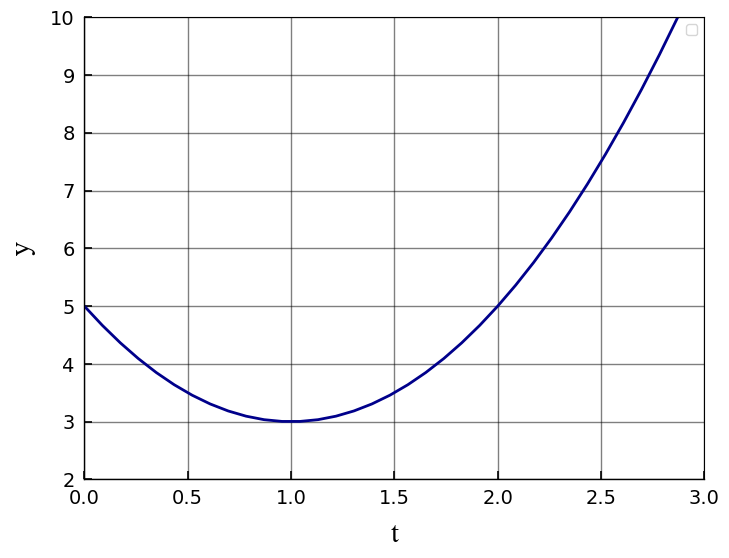

In [543]:
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(0,6, 70)
y = [func(i) for i in x]
# Создаем фигуру и оси
fig , ax = plt.subplots(figsize = (8,6))
ax.plot(x, y, color='darkblue', linewidth=2)
ax.set_xlim(0, 3)
ax.set_ylim(2,10)
#ax.set_title("Dependence of minimum gyration radius on iteration ", fontsize=20, pad=15)
ax.set_xlabel('t', fontsize=20, labelpad=10, fontname = "Times New Roman")
ax.set_ylabel("y", fontsize=20, labelpad=10,fontname = "Times New Roman")

ax.grid(axis = "both", color='black', linestyle='-', linewidth=1, alpha=0.5 )
#ax.set_xticks(np.arange(0, 160, 20))
plt.xticks(fontsize=14)
#ax.set_yticks(np.arange(1.7, 2.2, 0.1))
plt.yticks(fontsize=14)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params( axis='y',which = "major", length=6, direction = "in", pad = 7, width = 1.2)
ax.tick_params( axis='x',which = "major", length=6, direction = "in", pad = 7,width = 1.2)

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

ax.spines['left'].set_linewidth(1)  # Левая ось
ax.spines['left'].set_color("black")
ax.spines['bottom'].set_linewidth(1)  # Нижняя ось
ax.spines['bottom'].set_color("black")

# Показываем график
plt.legend()
plt.savefig(r'C:\Users\trinimate\Downloads\graph.png')
plt.show()